In [1]:
!pip install numpy pandas matplotlib seaborn

##  Step 1: Import Required Libraries

In [3]:
import  pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## Step 2: Load the Dataset

In [5]:
df = pd.read_csv("height-weight.csv")

In [6]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


## scatter plot

Text(0, 0.5, 'Weight')

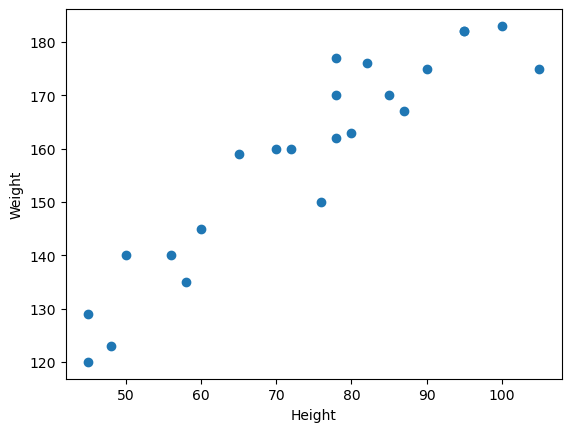

In [8]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Height')
plt.ylabel('Weight')

## correlation

In [10]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


<Axes: >

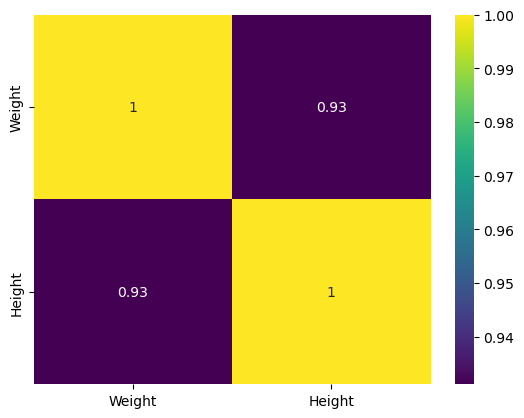

In [11]:
sns.heatmap(df.corr(),annot=True,cmap='viridis')

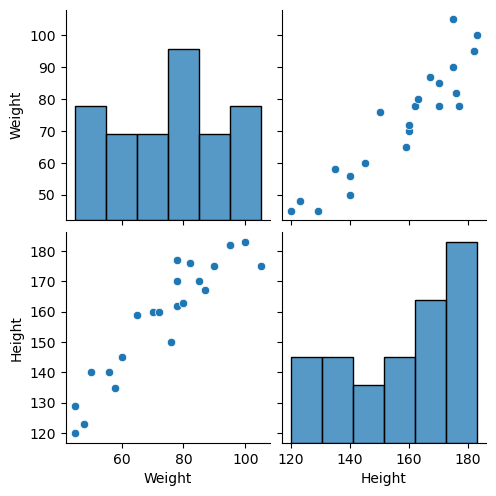

In [12]:
sns.pairplot(df)

## Step 3: Select Features (X) and Target (y)

In [14]:
X=df[['Weight']]
y=df['Height']

In [15]:
X

,Weight
0,45
1,58
2,48
3,60
4,70
5,78
6,80
7,90
8,95
9,78


In [16]:
y

0     120
1     135
2     123
3     145
4     160
5     162
6     163
7     175
8     182
9     170
10    176
11    182
12    175
13    183
14    170
15    177
16    140
17    159
18    150
19    167
20    129
21    140
22    160
Name: Height, dtype: int64

In [17]:
X.shape

(23, 1)

##  Step 4: Split the Data into Training and Testing Sets

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [21]:
X_train.shape

(17, 1)

In [22]:
X_test.shape

(6, 1)

## Standardization

In [24]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [25]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)
X_test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

In [26]:
X_train.shape

(17, 1)

##  Step 5: Initialize and Train the Linear Regression Model

In [28]:
from sklearn.linear_model import LinearRegression

In [29]:
regression=LinearRegression(n_jobs=-1)

In [30]:
regression

LinearRegression(n_jobs=-1)

In [31]:
regression.fit(X_train,y_train)

LinearRegression(n_jobs=-1)

In [32]:
?regression.fit

Signature: regression.fit(X, y, sample_weight=None)
Docstring:
Fit linear model.

Parameters
----------
X : {array-like, sparse matrix} of shape (n_samples, n_features)
    Training data.

y : array-like of shape (n_samples,) or (n_samples, n_targets)
    Target values. Will be cast to X's dtype if necessary.

sample_weight : array-like of shape (n_samples,), default=None
    Individual weights for each sample.

    .. versionadded:: 0.17
       parameter *sample_weight* support to LinearRegression.

Returns
-------
self : object
    Fitted Estimator.
File:      /opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_base.py
Type:      method

In [33]:
print(f"regression coefficient", regression.coef_)
print(f"regression intercept", regression.intercept_)

regression coefficient [17.2982057]
regression intercept 156.47058823529412


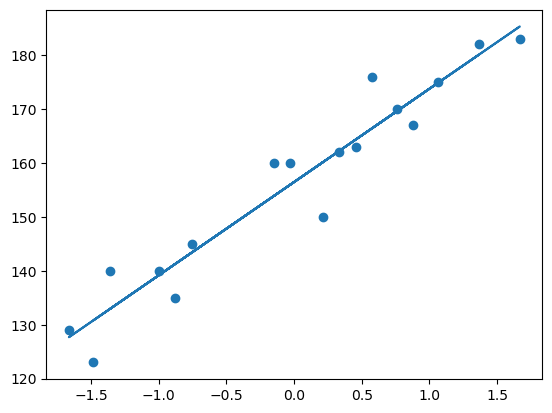

In [34]:
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train))

##  Step 6: Make Predictions on Test Data
1. predicted height output= intercept +coef_(Weights)
2. y_pred_test =156.470 + 17.29(X_test)

In [36]:
y_pred=regression.predict(X_test)

In [37]:
y_pred

array([162.26499721, 162.26499721, 127.68347133, 180.07972266,
       148.64197186, 190.55897293])

## Performance Metrics

In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [40]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

114.84069295228699
9.665125886795005
10.716374991212605


In [41]:
mse

114.84069295228699

In [42]:
from sklearn.metrics import r2_score

In [43]:
score=r2_score(y_test,y_pred)

## adjusted r2 square

In [45]:
ar2=1-(1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

In [46]:
ar2

0.6701033397476595

## using ols

In [48]:
!pip install statsmodels

In [49]:
import statsmodels.api as sm

In [50]:
model=sm.OLS(y_train,X_train).fit()

In [91]:
model.predict(X_test)

array([  5.79440897,   5.79440897, -28.78711691,  23.60913442,
        -7.82861638,  34.08838469])

In [93]:
model.summary()

/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=17
  res = hypotest_fun_out(*samples, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Tue, 15 Jul 2025   Prob (F-statistic):                       0.664
Time:                        22:25:09   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            17.2982     39.138      0.442      0.664     -65.671     100.267
==============================================================================
Omnibus:                        0.135   Durbin-Watson:                   0.002
Prob(Omnibus):                  0.935   Jarque-Bera (JB):                0.203
Skew:                          -0.166   Prob(JB):                        0.904
Kurtosis:                       2.581   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""